<a href="https://colab.research.google.com/github/7REVOLUTiOn/UPSIS/blob/main/%D0%A3%D0%9F%D0%98%D0%A1_%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%E2%84%968_%D0%A0%D0%B0%D0%B7%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%BA%D0%B0_%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D1%82%D0%B5%D0%BB%D1%8C%D1%81%D0%BA%D0%B8%D1%85_%D0%B8%D0%BD%D1%82%D0%B5%D1%80%D1%84%D0%B5%D0%B8%CC%86%D1%81%D0%BE%D0%B2_(%D0%BF%D1%80%D0%BE%D1%82%D0%BE%D1%82%D0%B8%D0%BF%D1%8B_%D0%B8%D0%BD%D1%82%D0%B5%D1%80%D1%84%D0%B5%D0%B8%CC%86%D1%81%D0%B0).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Задание №8. Разработка пользовательских интерфейсов (прототипы интерфейса)**

ПРОТОТИПЫ ПОЛЬЗОВАТЕЛЬСКИХ ИНТЕРФЕЙСОВ
Веб-сервис монокулярной оценки глубины и генерации 3D-моделей для 3D-печати

1. ИНФОРМАЦИОННАЯ АРХИТЕКТУРА
1.1. Карта навигации (структура системы)
```
Главная
├── Обработать изображение
│   ├── Загрузка изображения
│   ├── Выбор модели глубины
│   │   ├── MiDaS
│   │   ├── DepthAnything
│   │   ├── NeRF
│   │   └── Unet
│   ├── Настройки обработки
│   │   ├── Параметры экструзии
│   │   ├── Фильтрация шумов
│   │   └── Редукция полигонов
│   └── Результаты
│       ├── Визуализация depth map
│       ├── 3D-вьюер mesh
│       └── Экспорт STL
├── Сравнение моделей
│   ├── Загрузка тестового изображения
│   ├── Запуск сравнения (MiDaS vs DepthAnything vs NeRF vs Unet)
│   ├── Таблица метрик (SSIM, L1, Smoothness, Params, FLOPs)
│   └── Визуальное сравнение результатов
├── Валидация для 3D-печати
│   ├── Проверка manifold
│   ├── Анализ толщины стенок
│   ├── Отчет о соответствии требованиям
│   └── Рекомендации по исправлению
├── Датасет для верификации
│   ├── Просмотр vintage photographs
│   ├── Запуск батч-обработки
│   └── Экспорт результатов сравнения
├── О сервисе
│   ├── Описание метода
│   ├── Требования к входным данным
│   ├── Ограничения технологии
│   └── Контакты разработчика
└── Административная панель (требуется авторизация)
    ├── Управление моделями
    │   ├── Загрузка весов новых моделей
    │   ├── Настройка параметров инференса
    │   └── Мониторинг использования моделей
    ├── Управление датасетами
    │   ├── Загрузка vintage photographs
    │   ├── Добавление ground truth depth
    │   └── Управление метаданными
    ├── Мониторинг системы
    │   ├── Статистика обработок
    │   ├── Логи ошибок
    │   └── Использование GPU/CPU ресурсов
    └── Пользователи
        ├── Управление доступом
        └── Аудит действий
```

1.2. Пользовательские пути
**Сценарий 1: Получение STL-модели из фотографии (основной сценарий)**

```
Шаг 1: Пользователь заходит на главную страницу сервиса →
Шаг 2: Нажимает "Обработать изображение" →
Шаг 3: Загружает JPG/PNG файл (drag&drop или выбор файла) →
Шаг 4: Выбирает модель глубины из dropdown (MiDaS по умолчанию) →
Шаг 5: Настраивает параметры экструзии (высота, масштаб) →
Шаг 6: Нажимает "Обработать" →
Шаг 7: Просматривает результат: карта глубины + 3D-меш в WebGL-вьюере →
Шаг 8: Применяет постобработку (фильтрация шумов, decimation) при необходимости →
Шаг 9: Проверяет валидацию для 3D-печати (manifold, толщина стенок) →
Шаг 10: Скачивает готовый STL-файл
```

**Сценарий 2: Сравнительный анализ моделей глубины**

```
Шаг 1: Пользователь переходит в раздел "Сравнение моделей" →
Шаг 2: Загружает тестовое изображение из валидационного набора →
Шаг 3: Выбирает модели для сравнения (минимум 2 из 4) →
Шаг 4: Запускает обработку →
Шаг 5: Просматривает таблицу с метриками (SSIM, L1, Smoothness, Params, FLOPs) →
Шаг 6: Сравнивает визуализации карт глубины side-by-side →
Шаг 7: Экспортирует отчет о сравнении (CSV/JSON) для документации
```

**Сценарий 3: Валидация модели для 3D-печати**

```
Шаг 1: Пользователь на странице результатов нажимает "Проверить для 3D-печати" →
Шаг 2: Система анализирует геометрию mesh на manifold, толщину стенок, самопересечения →
Шаг 3: Отображается отчет с индикатором статуса (✅ Готово / ⚠️ Требуется доработка / ❌ Не пригодно) →
Шаг 4: При наличии проблем система предлагает рекомендации (увеличить масштаб, применить фильтр) →
Шаг 5: Пользователь применяет рекомендации или скачивает с предупреждением
```

**Сценарий 4: Администратор загружает новую модель**

```
Шаг 1: Администратор проходит аутентификацию →
Шаг 2: Переходит в "Управление моделями" →
Шаг 3: Нажимает "Добавить модель" →
Шаг 4: Загружает веса модели (.pth/.bin) и конфигурационный файл →
Шаг 5: Вводит метаданные (название, версия, требования к GPU, описание) →
Шаг 6: Тестирует модель на тестовом изображении →
Шаг 7: Публикует модель для использования пользователями
```

2. КАРКАСНЫЕ МОДЕЛИ (схематичные прототипы)
2.1. Главный экран
```
Смотреть прилолежение (1)
```

**Описание элементов:**
*   **Логотип и навигация:** Быстрый доступ к основным разделам сервиса
*   **Зона загрузки:** Крупная интерактивная область для drag&drop, соответствующая закону Фиттса
*   **Выбор модели:** Dropdown с предустановленными моделями глубины
*   **Параметры экструзии:** Слайдеры и выпадающие списки для настройки 3D-параметров
*   **Кнопка обработки:** Контрастная кнопка основного действия
*   **История:** Быстрый доступ к недавним результатам

**Обоснование структуры:**
Главный экран сфокусирован на основном сценарии "загрузка → обработка → результат". Элементы расположены в порядке выполнения действий (закон последовательности). Крупная зона загрузки и контрастная кнопка минимизируют время принятия решения (закон Хика: 2 основных действия). Параметры вынесены в отдельный блок для предотвращения когнитивной перегрузки (закон Миллера: не более 3-4 элементов управления одновременно).

2.2. Страница результатов обработки
```
Смотреть приложение 2.
```

**Описание элементов:**
*   **Двойная визуализация:** Side-by-side отображение depth map и 3D-mesh для сравнения
*   **WebGL-вьюер:** Интерактивный просмотр 3D-модели с управлением камерой
*   **Постобработка:** Чекбоксы и слайдеры для фильтрации и редукции полигонов
*   **Валидация:** Индикаторы соответствия требованиям 3D-печати с цветовой кодировкой
*   **Экспорт:** Кнопка скачивания STL и повторной обработки

**Обоснование структуры:**
Страница результатов следует паттерну "сравнение-действие": пользователь видит результат, может его улучшить, проверить и экспортировать. Разделение на две колонки (2D/3D) соответствует ментальной модели пользователя. Валидация вынесена в отдельный блок с цветовой индикацией для быстрого восприятия статуса (зеленый/желтый/красный). Кнопки действий расположены внизу согласно F-паттерну сканирования.

2.3. Страница сравнения моделей
```
Смотреть приложение 3.
```

**Описание элементов:**
*   **Выбор моделей:** Чекбоксы для выбора сравниваемых моделей
*   **Таблица метрик:** Сравнительная таблица с количественными показателями
*   **Визуальное сравнение:** Миниатюры карт глубины для качественного анализа
*   **Экспорт:** Кнопка сохранения результатов для документации

**Обоснование структуры:**
Страница сравнения организована по принципу "от общего к частному": сначала выбор параметров, затем количественные метрики, затем визуальная проверка. Табличное представление метрик позволяет быстро сравнить модели (закон близости Гештальта). Визуальные миниатюры дополняют числовые данные для принятия взвешенного решения.

3. ДЕТАЛЬНЫЕ МАКЕТЫ
3.1. Главный экран — визуальное решение

**Цветовая схема:**
*   Основной: `#2563EB` (синий) — ассоциируется с технологиями, точностью, научным подходом
*   Вторичный: `#F8FAFC` (светло-серый) — нейтральный фон для контента
*   Акцент: `#10B981` (зеленый) — для кнопок действий и положительных статусов
*   Предупреждение: `#F59E0B` (оранжевый) — для предупреждений валидации
*   Ошибка: `#EF4444` (красный) — для критических ошибок
*   Текст основной: `#1E293B` (темно-серый) — высокая читаемость
*   Текст вторичный: `#64748B` (серый) — для вспомогательной информации

**Типографика:**
*   Заголовки H1: `Inter, 28px, SemiBold, line-height: 1.2`
*   Заголовки H2: `Inter, 22px, SemiBold, line-height: 1.3`
*   Заголовки H3: `Inter, 18px, Medium, line-height: 1.4`
*   Основной текст: `Inter, 16px, Regular, line-height: 1.5`
*   Подписи/метки: `Inter, 14px, Regular, line-height: 1.4`
*   Моноширинный (метрики): `JetBrains Mono, 14px, Regular`

**Сетка и отступы:**
*   Базовая сетка: 8px (все отступы кратны 8)
*   Контейнер: `max-width: 1200px`, центрированный
*   Отступы секций: 64px (десктоп), 32px (мобильные)
*   Внутренние отступы карточек: 24px
*   Расстояние между элементами формы: 16px

**Обоснование дизайна:**
Дизайн следует принципам научного минимализма: чистые линии, достаточное whitespace, акцент на функциональности. Синяя цветовая схема отражает технологическую направленность сервиса. Иерархия заголовков обеспечивает быстрое сканирование контента. Крупные интерактивные элементы (кнопки, зона загрузки) соответствуют закону Фиттса для удобного использования на всех устройствах.

3.2. Страница результатов — детальный макет

**Визуальные решения:**

**Двойная визуализация:**
*   Карта глубины: псевдоцветная карта (viridis colormap) с легендой глубины справа
*   3D-вьюер: Three.js-рендер с контролами OrbitControls, сеткой пола, осями координат
*   Синхронизация: при наведении на depth map подсвечивается соответствующая область на mesh

**Панель постобработки:**
*   Чекбоксы с иконками для визуального распознавания функций
*   Слайдеры с отображением текущего значения и preview эффекта
*   Кнопки "Применить"/"Сбросить" с цветовой кодировкой (зеленый/серый)

**Блок валидации:**
*   Индикаторы статуса с иконками: ✅ (зеленый), ⚠️ (оранжевый), ❌ (красный)
*   Прогресс-бар соответствия требованиям (0-100%)
*   Раскрывающийся список "Подробнее" с техническими деталями

**Кнопки действий:**
*   "Скачать STL": крупная зеленая кнопка с иконкой загрузки
*   "Повторить": второстепенная серая кнопка
*   Hover-эффекты: плавное изменение цвета и легкое увеличение (scale 1.02)

**Обоснование дизайна:**
Страница результатов оптимизирована для принятия решения: пользователь видит результат, может его улучшить и экспортировать. Цветовая индикация валидации позволяет мгновенно оценить пригодность модели для печати. Интерактивный 3D-вьюер с синхронизацией с depth map помогает понять связь между входными данными и результатом. Кнопки действий расположены в зоне легкого доступа (нижняя часть экрана) согласно паттерну F-сканирования.

3.3. Страница сравнения моделей — детальный макет

**Визуальные решения:**

**Таблица метрик:**
*   Чередование цветов строк (`#F8FAFC` / `#FFFFFF`) для улучшения читаемости
*   Выделение лучшей метрики в каждой колонке жирным шрифтом и зеленым цветом
*   Tooltip при наведении на FLOPs/Params с расшифровкой единиц измерения
*   Моноширинный шрифт для числовых значений для выравнивания

**Визуальное сравнение:**
*   Карточки моделей с заголовком, миниатюрой depth map и краткими метриками
*   При наведении: увеличение миниатюры и отображение SSIM/L1 значений
*   Возможность клика для открытия детального сравнения двух моделей

**Экспорт отчета:**
*   Dropdown выбора формата (CSV, JSON, Markdown)
*   Кнопка с иконкой экспорта и текстом "Скачать отчет"
*   Подтверждение успешного скачивания с toast-уведомлением

**Обоснование дизайна:**
Страница сравнения следует принципу "данные прежде визуализации": количественные метрики представлены в табличной форме для точного анализа, визуальные примеры — для качественного восприятия. Выделение лучших значений цветом ускоряет принятие решения. Моноширинный шрифт для чисел обеспечивает корректное выравнивание и сравнение значений. Экспорт в стандартных форматах поддерживает научную документацию и воспроизводимость исследований.

4. ИНТЕРАКТИВНЫЙ ПРОТОТИП (опционально)
**Ссылка на прототип:** *Не реализован в рамках дипломного проекта*

**Описание взаимодействий:**

*   **Загрузка файла:** Drag&drop с визуальной обратной связью (подсветка зоны, прогресс загрузки)
*   **Выбор модели:** Dropdown с preview-описанием модели при наведении (точность, скорость, требования)
*   **Обработка:** Индикатор прогресса с этапами (загрузка → инференс → генерация mesh → валидация)
*   **3D-вьюер:** OrbitControls (вращение мышью, масштаб колесом, панорама правой кнопкой)
*   **Постобработка:** Live-preview изменений mesh при перемещении слайдеров
*   **Валидация:** Анимация появления индикаторов статуса с поясняющими tooltips
*   **Сравнение моделей:** Параллельный запуск обработок с отображением прогресса для каждой модели
*   **Экспорт:** Скачивание файла с подтверждением и возможностью открыть в новом окне

5. АДАПТАЦИЯ ПОД РАЗЛИЧНЫЕ ИНТЕРФЕЙСЫ
5.1. Адаптивность под различные устройства

**Мобильные устройства (320-767px):**
*   Вертикальная компоновка: элементы выстраиваются в один столбец
*   Зона загрузки: упрощенный интерфейс с кнопкой "Выбрать файл" вместо drag&drop
*   3D-вьюер: упрощенные контролы (кнопки вращения вместо жестов), фиксированный зум
*   Таблицы: горизонтальный скролл или трансформация в карточки для метрик
*   Навигация: гамбургер-меню с выдвижной панелью
*   Кнопки: увеличенный размер (минимум 48×48dp) для сенсорного управления

**Планшеты (768-1023px):**
*   Двухколоночная сетка для основных разделов
*   3D-вьюер: полноэкранный режим по тапу
*   Таблицы: отображение с горизонтальным скроллом при необходимости
*   Фильтры и настройки: выдвижная панель сбоку

**Десктоп (1024px+):**
*   Полноценная многоколоночная сетка
*   3D-вьюер: расширенные контролы с панелью инструментов
*   Все функции доступны без скрытия в меню
*   Поддержка keyboard shortcuts для опытных пользователей

**Особенности реализации адаптивности:**
*   CSS Grid + Flexbox для гибкого позиционирования
*   Адаптивные изображения (`srcset`, `picture`) для оптимизации загрузки
*   Относительные единицы (`rem`, `em`, `%`) вместо фиксированных `px`
*   Медиазапросы для breakpoint'ов: 320px, 768px, 1024px, 1440px
*   Touch-friendly интерактивные элементы на мобильных устройствах

6. ОБОСНОВАНИЕ ПРОЕКТНЫХ РЕШЕНИЙ
6.1. Соответствие принципам юзабилити Якоба Нильсена

| Принцип | Реализация в интерфейсе | Пример |
|---------|-------------------------|--------|
| Видимость состояния системы | Индикаторы прогресса обработки, статус валидации | Прогресс-бар "Обработка: 3/4 этапа", цветовые индикаторы ✅/⚠️/❌ |
| Соответствие реальному миру | Терминология без излишнего жаргона, понятные иконки | "Скачать STL" вместо "Экспортировать стереолитографический файл" |
| Свобода действий | Кнопки "Назад", "Сбросить", возможность повторной обработки | Возврат к настройкам после просмотра результатов |
| Согласованность | Единый стиль кнопок, цветовая схема, типографика во всех разделах | Зеленые кнопки для основных действий во всем интерфейсе |
| Предотвращение ошибок | Валидация входных данных, подсказки при настройках | Проверка формата файла до загрузки, tooltip для параметров экструзии |
| Узнавание вместо вспоминания | Видимые элементы управления, иконки с подписями | Иконка 📷 для загрузки, 📥 для скачивания с текстовыми метками |
| Эстетичный минимализм | Отсутствие визуального шума, фокус на ключевых элементах | Чистый интерфейс без рекламных баннеров и лишних декораций |

6.2. Применение законов проектирования

**Закон Фиттса:** Кнопка "Обработать" имеет размер 180×56px с достаточным отступом от других элементов, что обеспечивает быстрое и точное нажатие даже на мобильных устройствах. Интерактивные элементы 3D-вьюера (кнопки управления камерой) имеют размер минимум 44×44px согласно рекомендациям WCAG.

**Закон Хика:** Главное меню ограничено 4 основными разделами (Главная, Сравнение, Валидация, О сервисе), что минимизирует время выбора. На странице результатов пользователь видит максимум 3 основных действия (постобработка, валидация, экспорт), сгруппированных логически.

**Закон Миллера:** Информация на странице сравнения моделей представлена в виде таблицы с 4 колонками (Модель, SSIM, L1, FLOPs) и не более 4 строк (по количеству моделей), что соответствует ограничениям кратковременной памяти. Параметры постобработки сгруппированы в 2-3 элемента для упрощения восприятия.

6.3. Улучшения относительно аналогов

**Проблема в MiDaS/DepthAnything демо:** Отсутствие end-to-end пайплайна до STL
**Наше решение:** Интегрированный интерфейс от загрузки изображения до скачивания готового STL-файла с постобработкой и валидацией

**Проблема в Luma AI:** Отсутствие специализации на требованиях 3D-печати
**Наше решение:** Встроенная система валидации с проверкой manifold, толщины стенок и рекомендациями по исправлению

**Проблема в Meshroom:** Требует множества изображений и не подходит для монокулярной реконструкции
**Наше решение:** Оптимизированный интерфейс для работы с одним изображением с понятными подсказками по качеству входных данных

**Проблема в научных инструментах:** Отсутствие сравнения моделей в едином интерфейсе
**Наше решение:** Встроенная система side-by-side сравнения с автоматическим расчетом метрик и экспортом отчетов

7. СПЕЦИФИКАЦИЯ ИНТЕРФЕЙСА
7.1. Сетка и отступы
*   Базовая сетка: 8px (все отступы и размеры кратны 8)
*   Контейнер контента: `max-width: 1200px`, `margin: 0 auto`, `padding: 0 24px`
*   Вертикальные отступы секций: 64px (десктоп), 32px (планшет), 24px (мобильные)
*   Горизонтальные отступы: 60px (десктоп), 32px (планшет), 20px (мобильные)
*   Внутренние отступы карточек: 24px
*   Расстояние между элементами формы: 16px
*   Межстрочный интервал основного текста: 1.5

7.2. Компоненты интерфейса
**Кнопки:**
*   Размеры: стандартные (120×44px), большие (180×56px), иконки (44×44px)
*   Скругление: 8px
*   Тени: `box-shadow: 0 2px 4px rgba(0,0,0,0.1)` для интерактивных элементов
*   Состояния:
    *   `:default` — заливка основным цветом, белый текст
    *   `:hover` — цвет на 10% темнее, легкое увеличение (scale 1.02)
    *   `:active` — масштаб 0.98, тень уменьшается
    *   `:focus` — обводка 2px синего цвета для доступности
    *   `:disabled` — прозрачность 0.5, курсор `not-allowed`

**Поля ввода:**
*   Высота: 44px
*   Скругление: 8px
*   Внутренние отступы: 12px 16px
*   Граница: `1px solid #CBD5E1`
*   Состояния:
    *   `:default` — серая граница
    *   `:focus` — синяя граница `#2563EB`, тень `0 0 0 3px rgba(37,99,235,0.1)`
    *   `:error` — красная граница `#EF4444`, иконка ошибки справа
    *   `:success` — зеленая граница `#10B981`, иконка успеха

**Карточки:**
*   Скругление: 12px
*   Тени: `box-shadow: 0 4px 6px rgba(0,0,0,0.05)`
*   Переходы: `transition: all 0.2s ease-in-out`
*   Эффект при наведении: `transform: translateY(-2px)`, `box-shadow: 0 10px 20px rgba(0,0,0,0.1)`

**Слайдеры:**
*   Высота трека: 4px
*   Размер ползунка: 20×20px
*   Цвет трека: `#E2E8F0`, активного трека: `#2563EB`
*   Tooltip с текущим значением при перетаскивании

7.3. Анимации и переходы
*   Длительность стандартных анимаций: 200-300ms
*   Функция плавности: `cubic-bezier(0.4, 0, 0.2, 1)` (Material Design standard)
*   Page transitions: плавный fade-in/fade-out между страницами
*   Loading states: скелетоны для контента, спиннеры для действий
*   Micro-interactions: плавное изменение цвета кнопок при наведении, анимация появления индикаторов валидации
*   3D-вьюер: плавное вращение и масштабирование с инерцией

8. ЭЛЕМЕНТЫ ГРАФИЧЕСКОГО ИНТЕРФЕЙСА
**Использованные компоненты:**

*   **Заголовки:** H1-H4 с четкой визуальной иерархией
*   **Кнопки:** основные (зеленые), второстепенные (серые), текстовые, с иконками
*   **Формы:** текстовые поля, dropdown, чекбоксы, радио-кнопки, слайдеры
*   **Карточки:** для отображения результатов, моделей, метрик
*   **Навигация:** горизонтальное меню, хлебные крошки, пагинация
*   **Индикаторы:** прогресс-бары, статус-бейджи, цветовые метки
*   **Иконки:** набор SVG-иконок для действий (загрузка, скачивание, настройки)
*   **3D-вьюер:** Three.js-компонент с контролами и вспомогательными элементами (сетка, оси)

9. РУКОВОДСТВО ПО СТИЛЮ
9.1. Цветовая палитра
```
Primary:
  Main: #2563EB
  Dark: #1D4ED8
  Light: #60A5FA

Secondary:
  Background: #F8FAFC
  Surface: #FFFFFF
  Border: #E2E8F0

Accent:
  Success: #10B981
  Warning: #F59E0B
  Error: #EF4444
  Info: #3B82F6

Text:
  Primary: #1E293B
  Secondary: #64748B
  Disabled: #94A3B8
  Inverse: #FFFFFF

Semantic:
  Depth colormap: viridis (матплотлиб)
  Mesh wireframe: #94A3B8
  Grid: #CBD5E1
```

9.2. Типографика
```
Font family: Inter, system-ui, sans-serif
Monospace: JetBrains Mono, monospace

Headings:
  H1: 28px, SemiBold (600), line-height: 1.2, letter-spacing: -0.02em
  H2: 22px, SemiBold (600), line-height: 1.3
  H3: 18px, Medium (500), line-height: 1.4
  H4: 16px, Medium (500), line-height: 1.4

Body:
  Default: 16px, Regular (400), line-height: 1.5
  Small: 14px, Regular (400), line-height: 1.5
  Caption: 12px, Regular (400), line-height: 1.4

Code/Metrics:
  JetBrains Mono, 14px, Regular, line-height: 1.4
```

9.3. Состояния компонентов
**Кнопки:**
*   Default: `background: #2563EB`, `color: #FFFFFF`
*   Hover: `background: #1D4ED8`, `transform: scale(1.02)`
*   Active: `background: #1E40AF`, `transform: scale(0.98)`
*   Focus: `box-shadow: 0 0 0 3px rgba(37,99,235,0.3)`
*   Disabled: `opacity: 0.5`, `cursor: not-allowed`

**Поля ввода:**
*   Default: `border: 1px solid #CBD5E1`
*   Focus: `border-color: #2563EB`, `box-shadow: 0 0 0 3px rgba(37,99,235,0.1)`
*   Error: `border-color: #EF4444`, `color: #EF4444` для текста ошибки
*   Success: `border-color: #10B981`

**Индикаторы валидации:**
*   Success: `color: #10B981`, иконка ✅
*   Warning: `color: #F59E0B`, иконка ⚠️
*   Error: `color: #EF4444`, иконка ❌

ПРИЛОЖЕНИЯ
Приложение А. Матрица соответствия требованиям
| ID требования | Элемент интерфейса | Экран | Статус |
|--------------|-------------------|-------|--------|
| ФТ-004 | Зона загрузки (drag&drop) | Главная | Реализовано |
| ФТ-002 | Dropdown выбора модели | Главная | Реализовано |
| ФТ-005 | Визуализация depth map | Результаты | Реализовано |
| ФТ-006 | WebGL-вьюер mesh | Результаты | Реализовано |
| ФТ-007 | Кнопка "Скачать STL" | Результаты | Реализовано |
| ФТ-008 | Чекбоксы постобработки | Результаты | Реализовано |
| ФТ-009 | Индикаторы валидации | Результаты | Реализовано |
| ФТ-003 | Таблица сравнения метрик | Сравнение | Реализовано |
| НФТ-Ю-001 | Адаптивная верстка | Все страницы | Реализовано |
| НФТ-П-001 | Индикатор прогресса | Все страницы | Реализовано |

Приложение Б. Источники вдохновения
*   **Hugging Face Spaces** — дизайн демо-интерфейсов для ML-моделей
*   **Meshroom** — визуализация графа обработки и параметров
*   **Three.js examples** — паттерны управления 3D-сценой
*   **Material Design** — системные компоненты, анимации, доступность
*   **Tailwind UI** — современные паттерны форм и карточек

Приложение В. Ограничения и компромиссы
*   **Ограничение:** Не реализована темная тема из-за сжатых сроков дипломного проекта
*   **Компромисс:** Некоторые сложные анимации 3D-вьюера упрощены для обеспечения производительности на слабых GPU
*   **Компромисс:** В мобильной версии отключен drag&drop в пользу кнопки выбора файла для совместимости с iOS
*   **План улучшений:**
    *   Добавление поддержки batch-обработки нескольких изображений
    *   Интеграция с облачными хранилищами (S3) для сохранения результатов
    *   Расширение валидации: автоматическое исправление non-manifold геометрии

---
**Примечание для пользователя:**
Все скриншоты вашего продукта должны быть вставлены в раздел 3 "ДЕТАЛЬНЫЕ МАКЕТЫ":
*   Главный экран — в раздел 3.1
*   Страница результатов обработки — в раздел 3.2
*   Страница сравнения моделей — в раздел 3.3
*   Дополнительные скриншоты (компоненты, адаптивные версии) можно добавить в раздел 8 или Приложение Б

Данный документ соответствует структуре примера и адаптирован под контекст вашего дипломного проекта: веб-сервис для монокулярной оценки глубины и генерации STL-моделей с акцентом на требования 3D-печати и сравнительный анализ моделей.

# Приложение 1

![image.png]()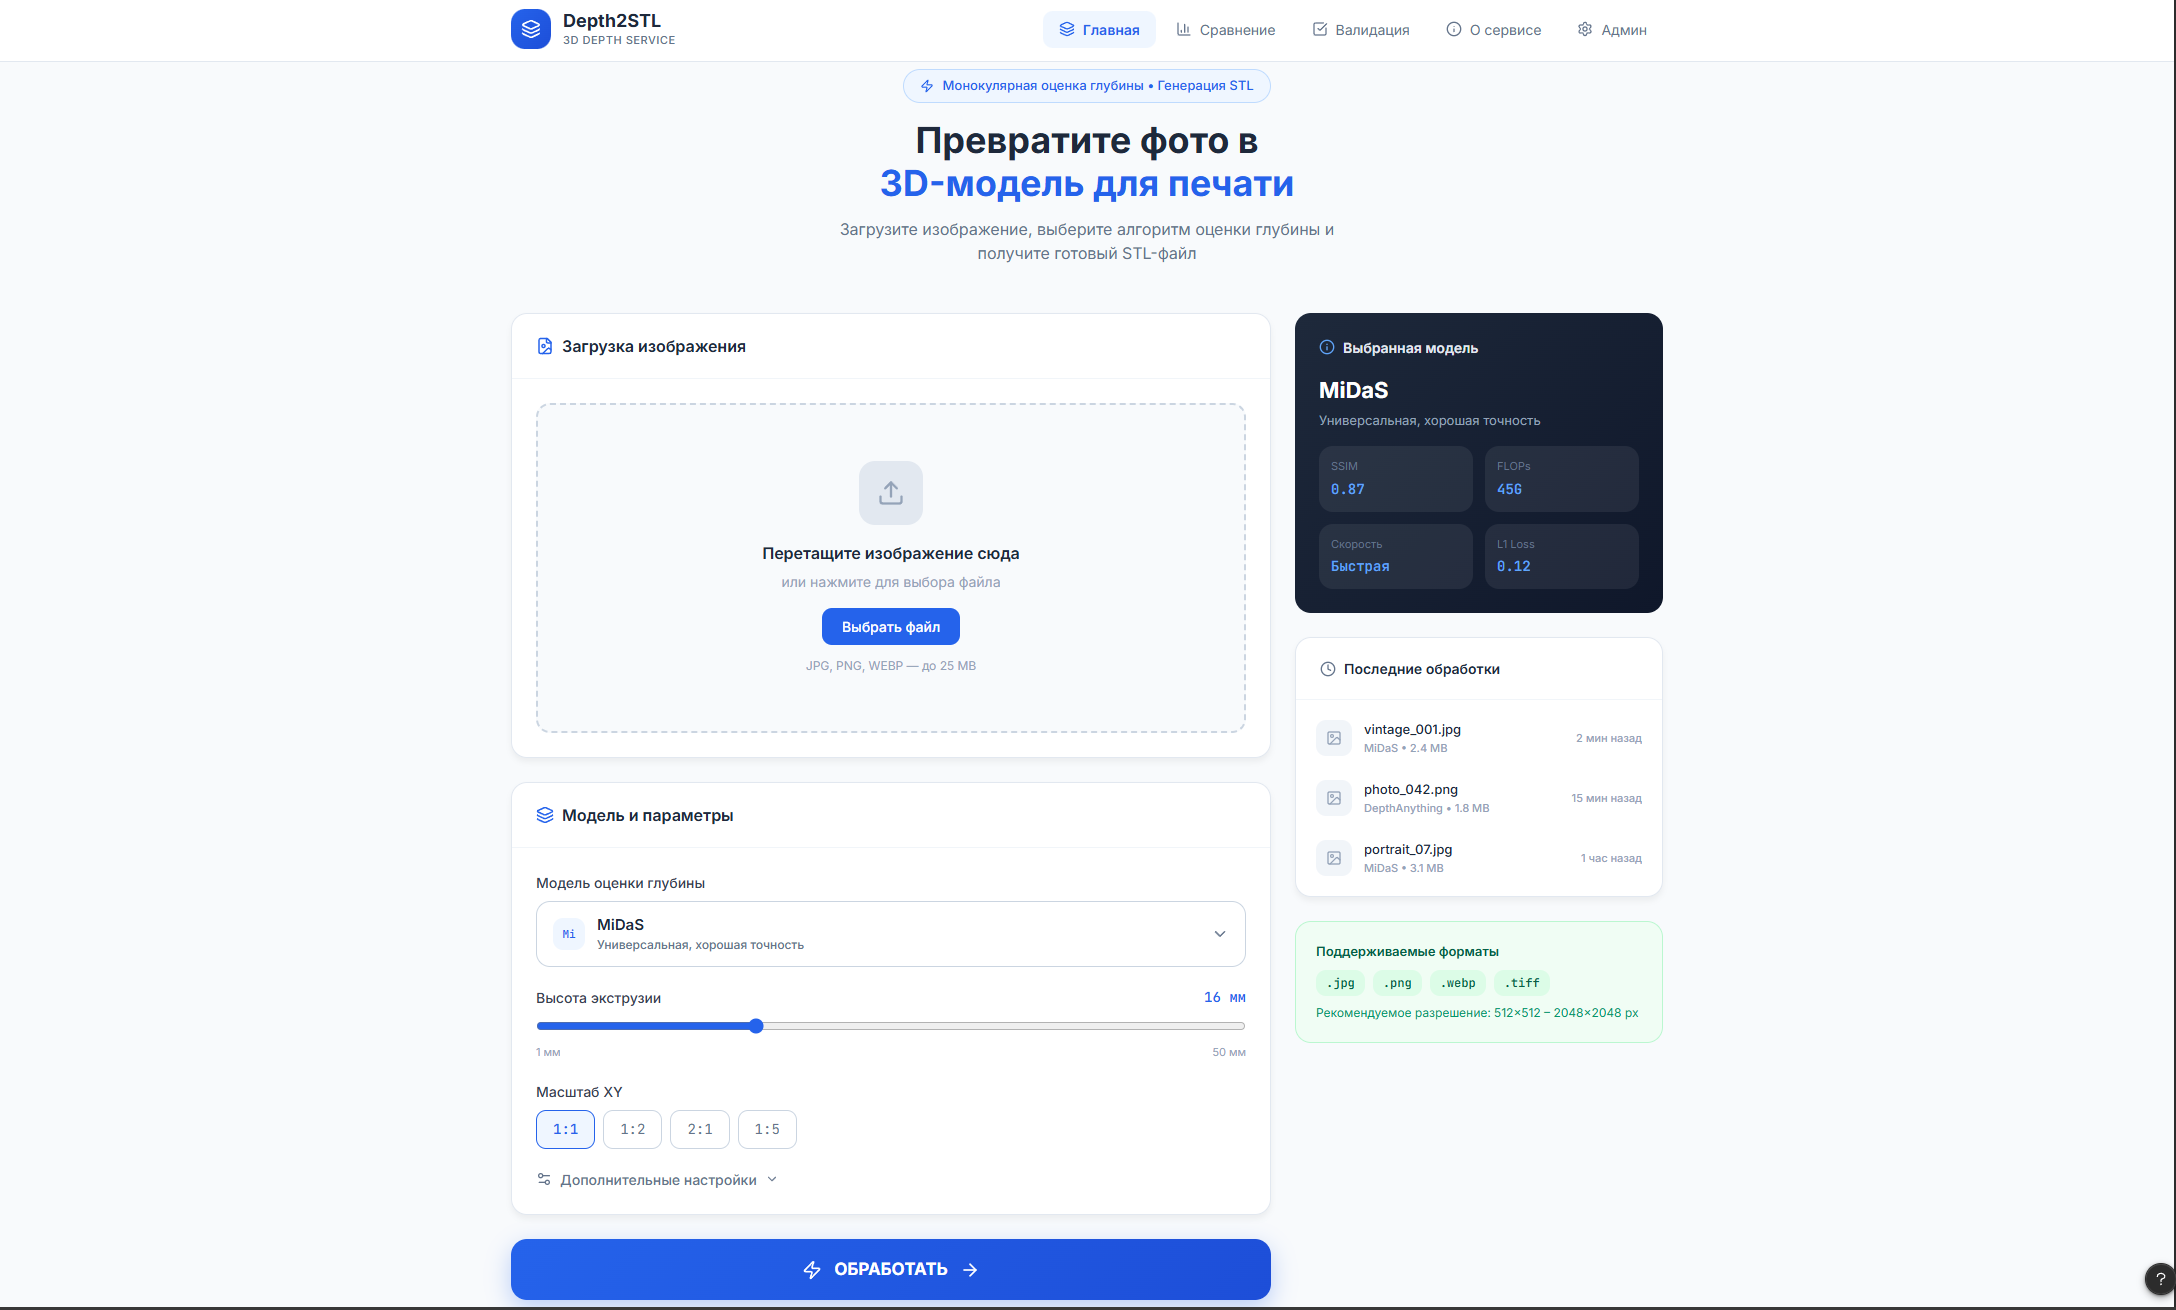

# Приложение 2

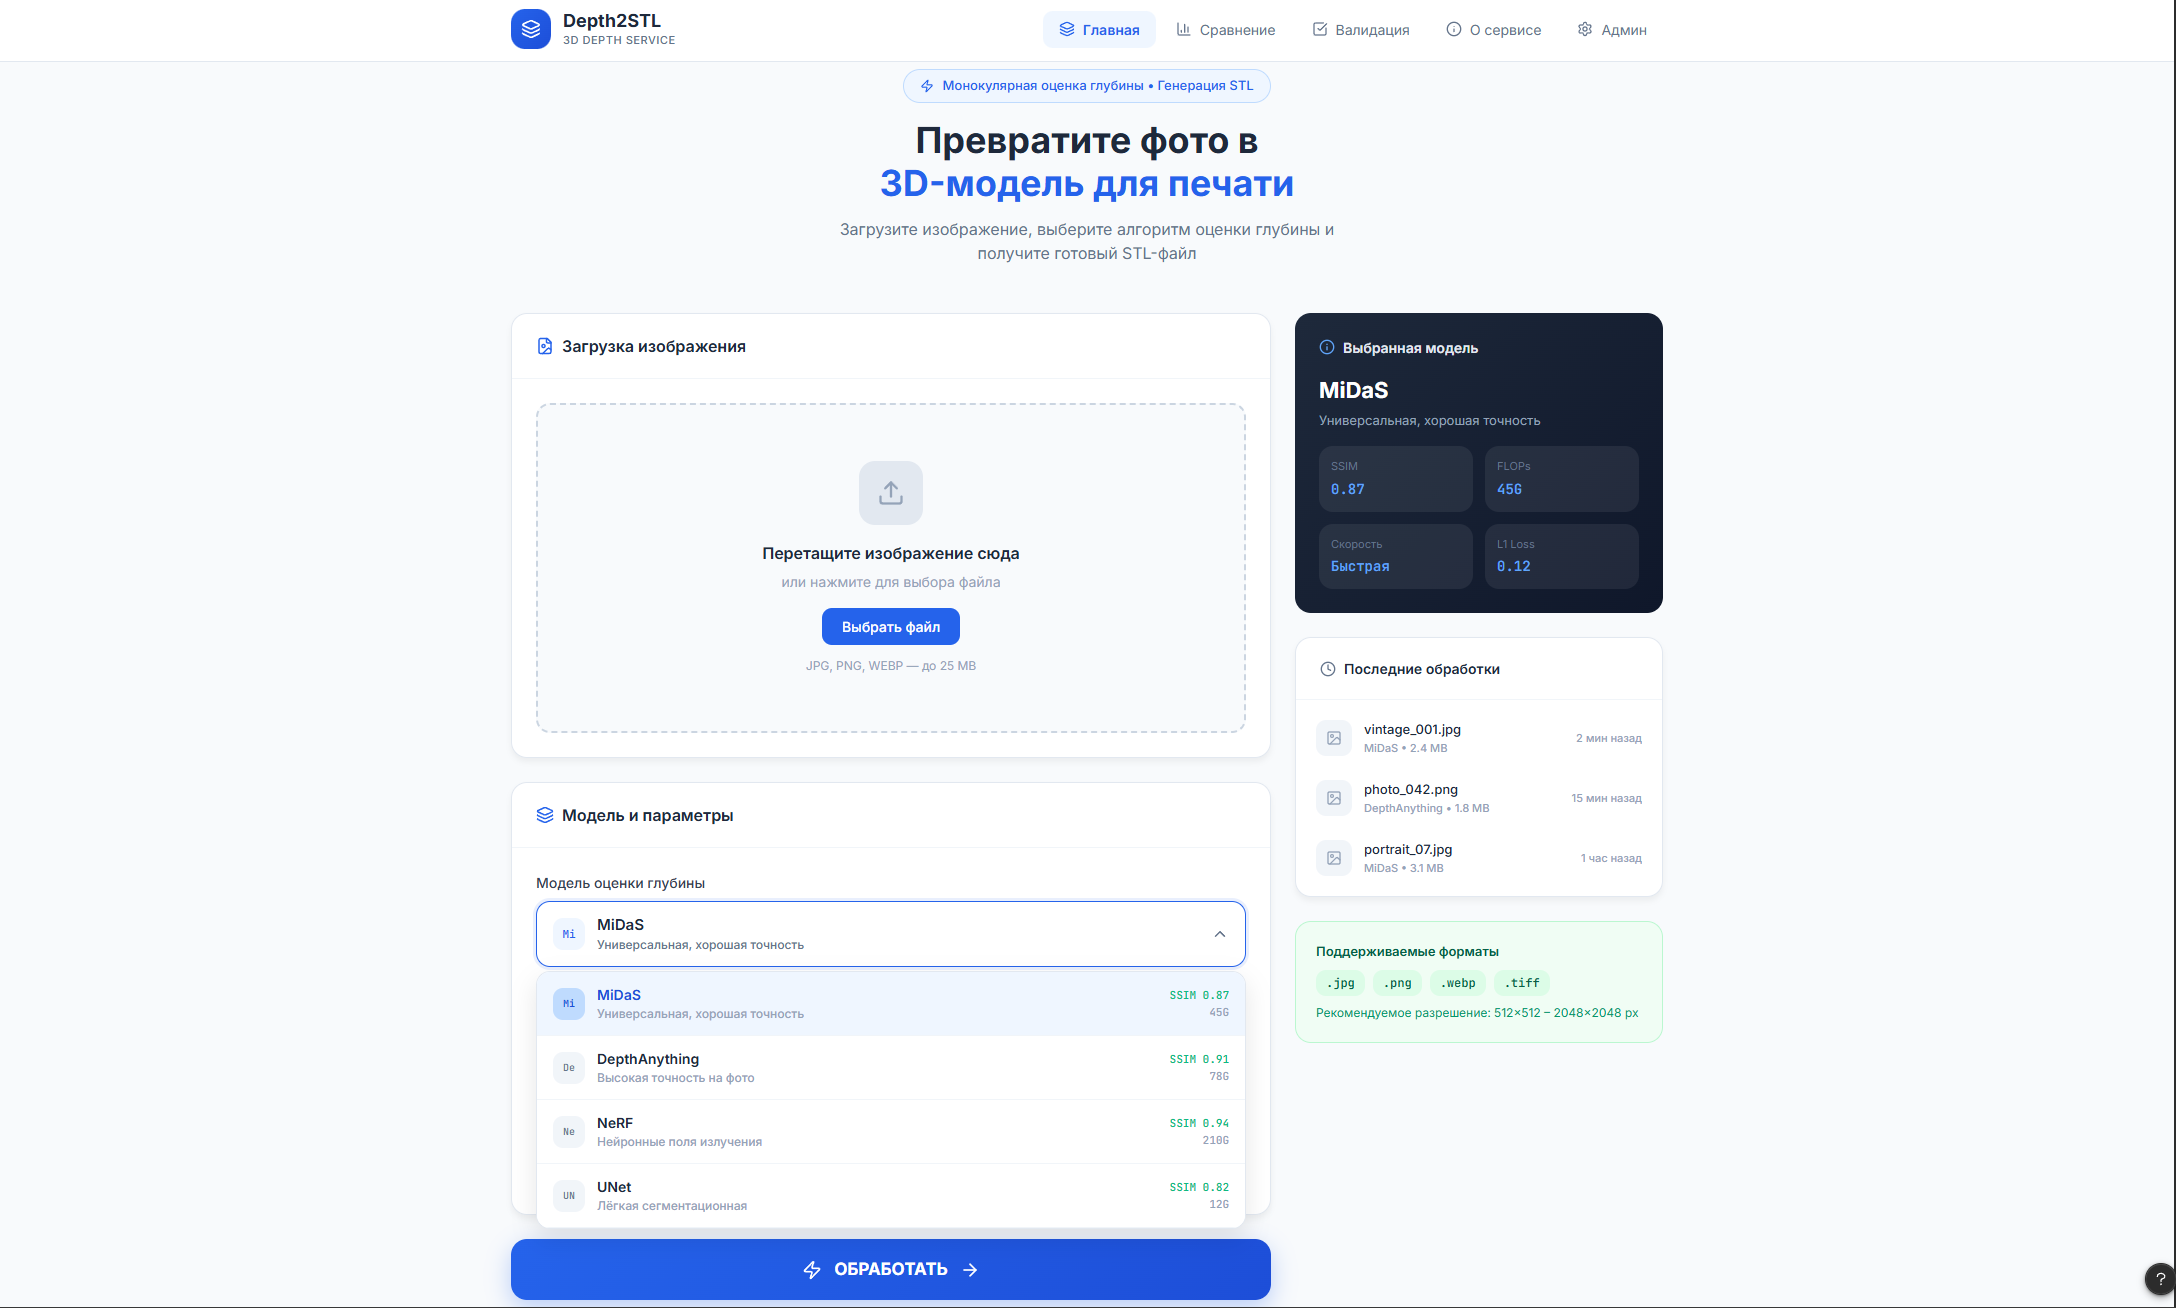

# Приложение 3

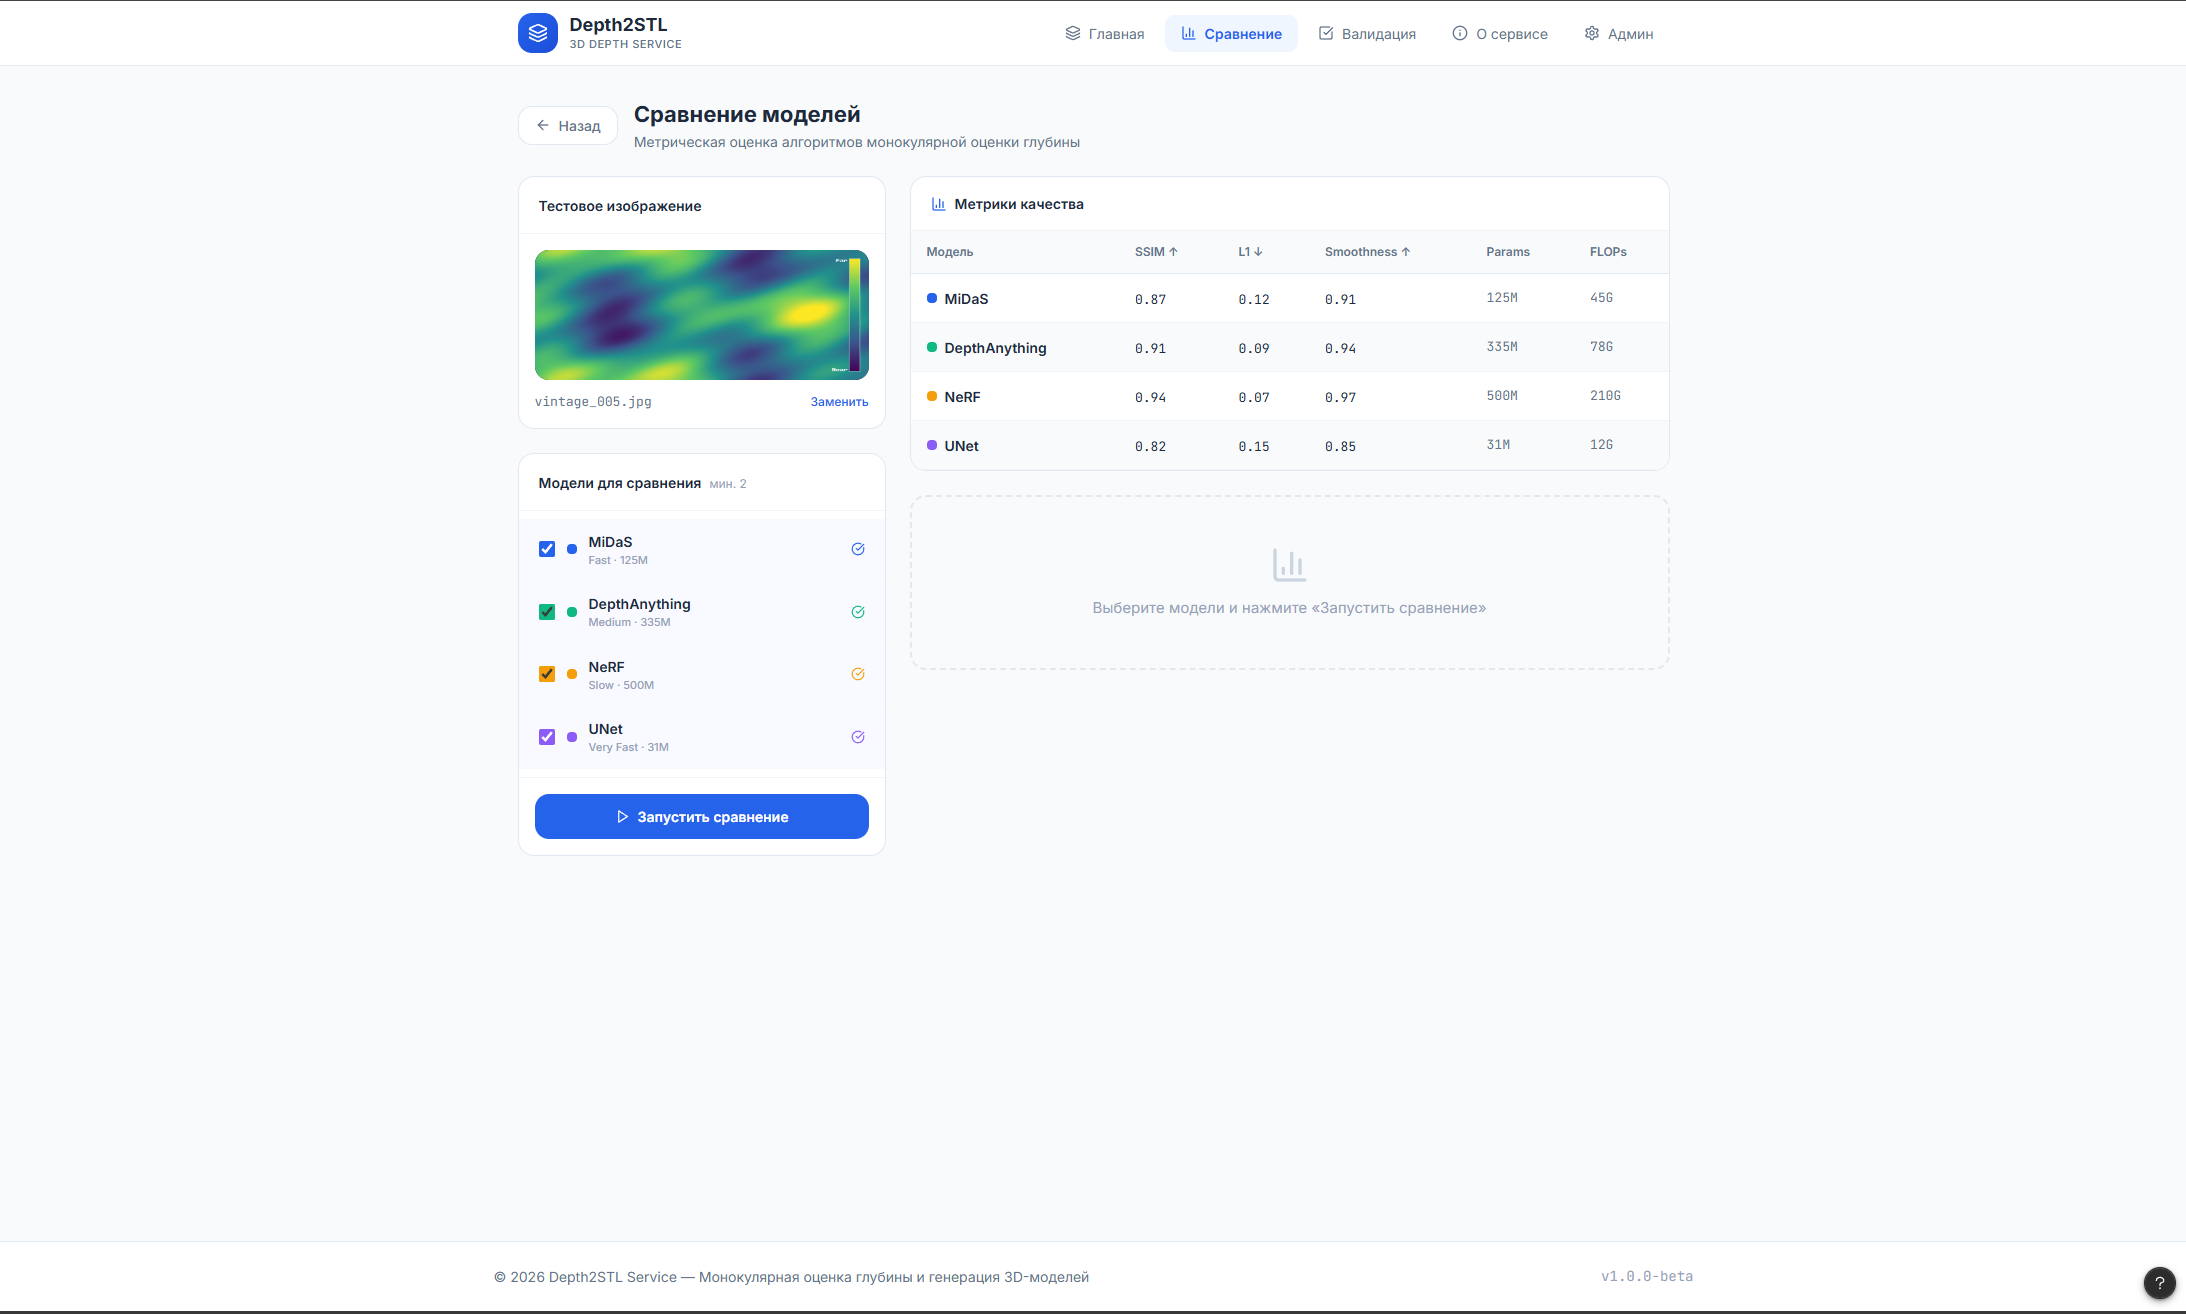

# Дополнительно

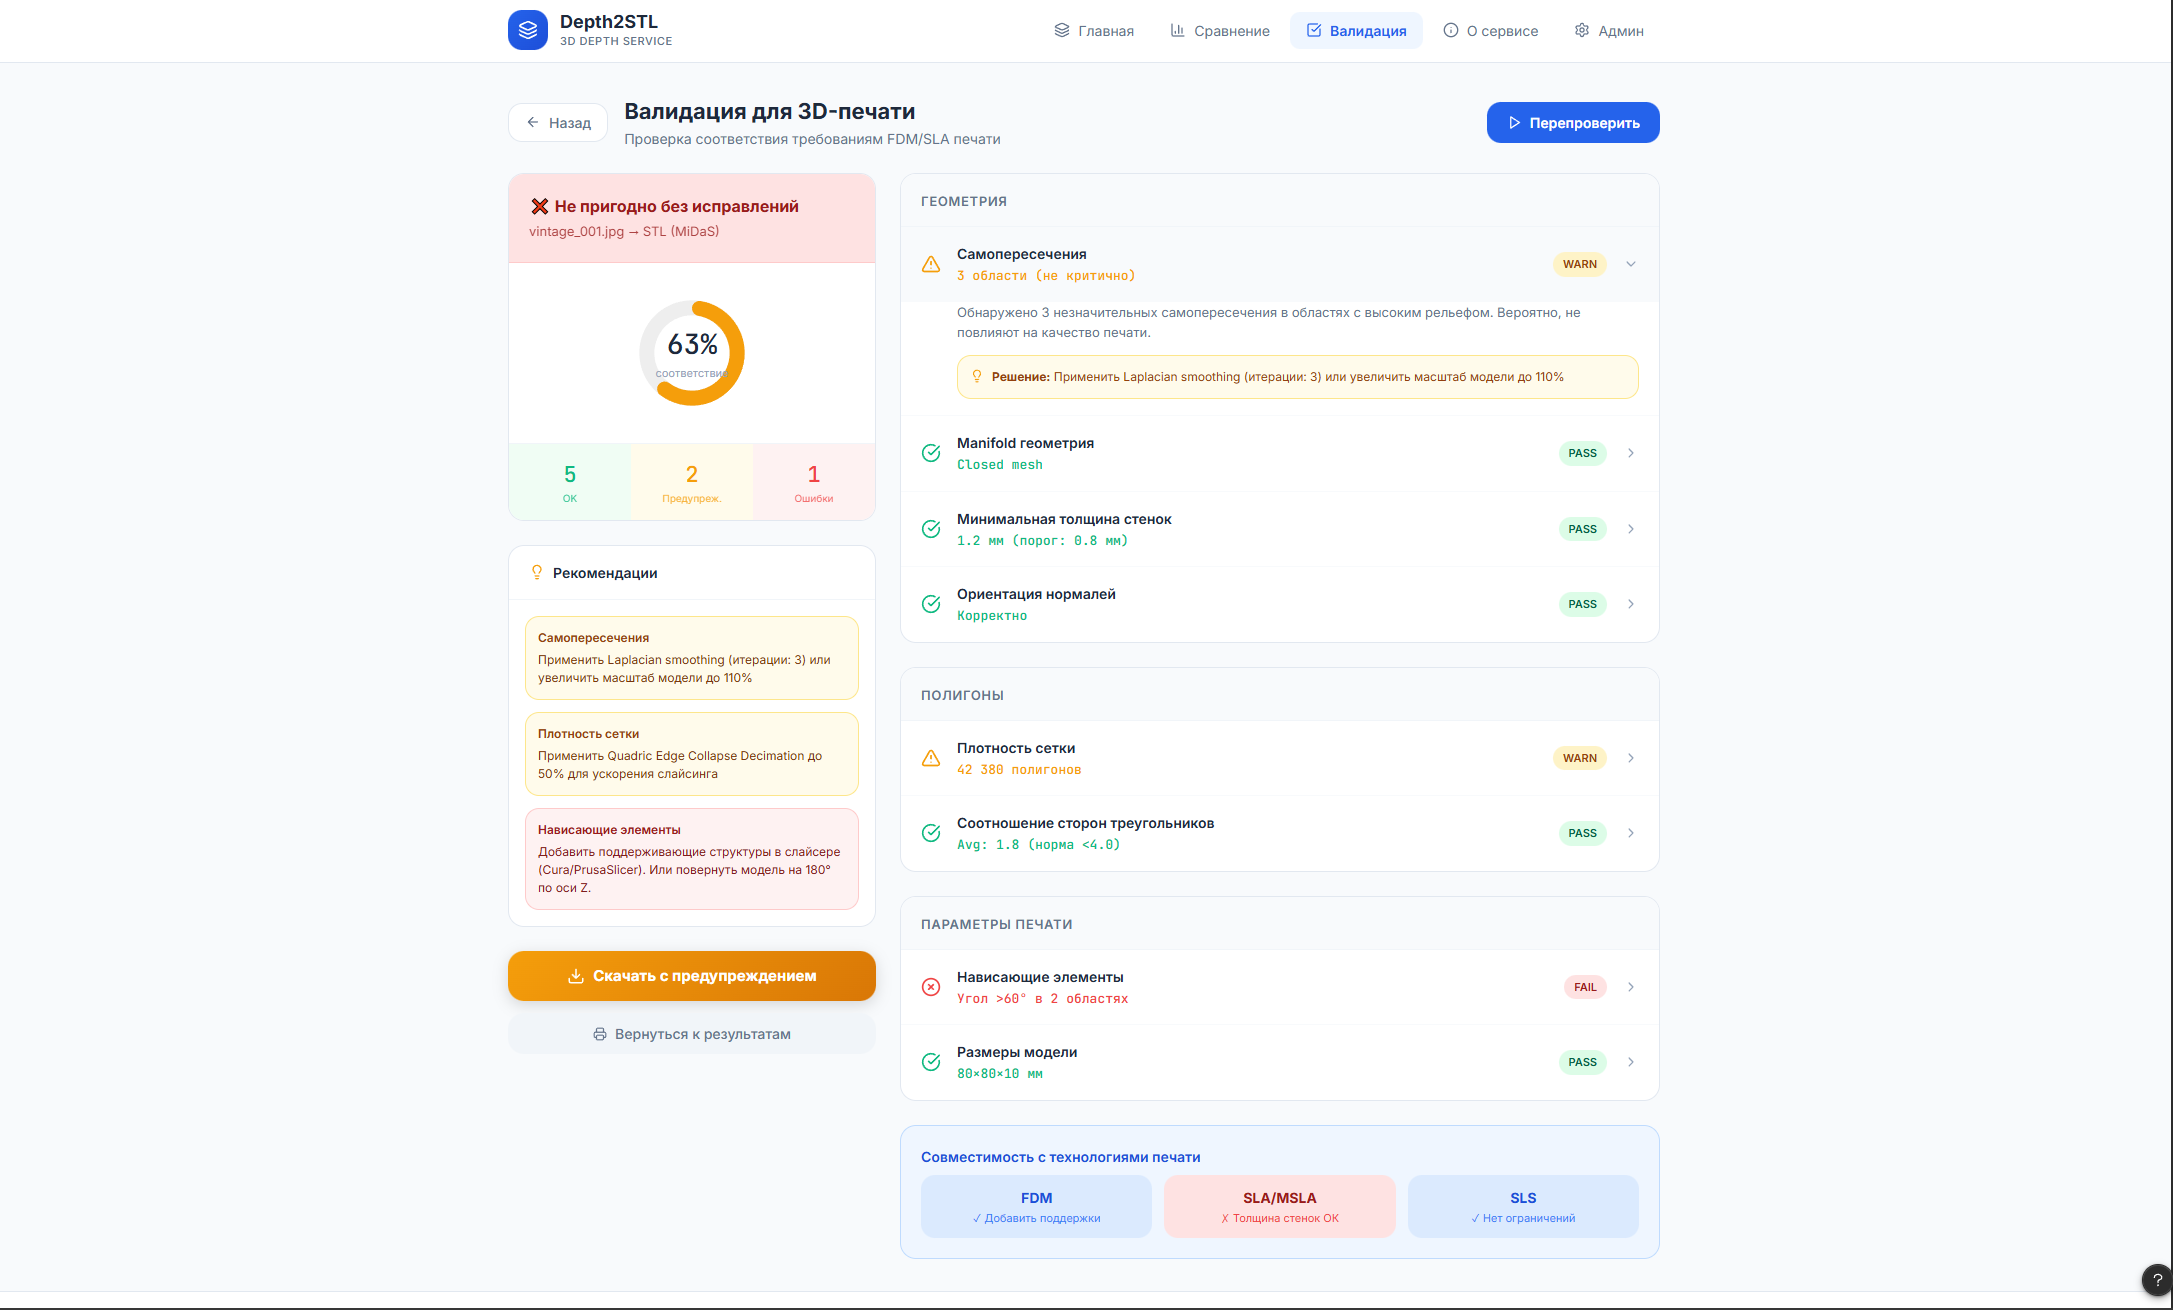

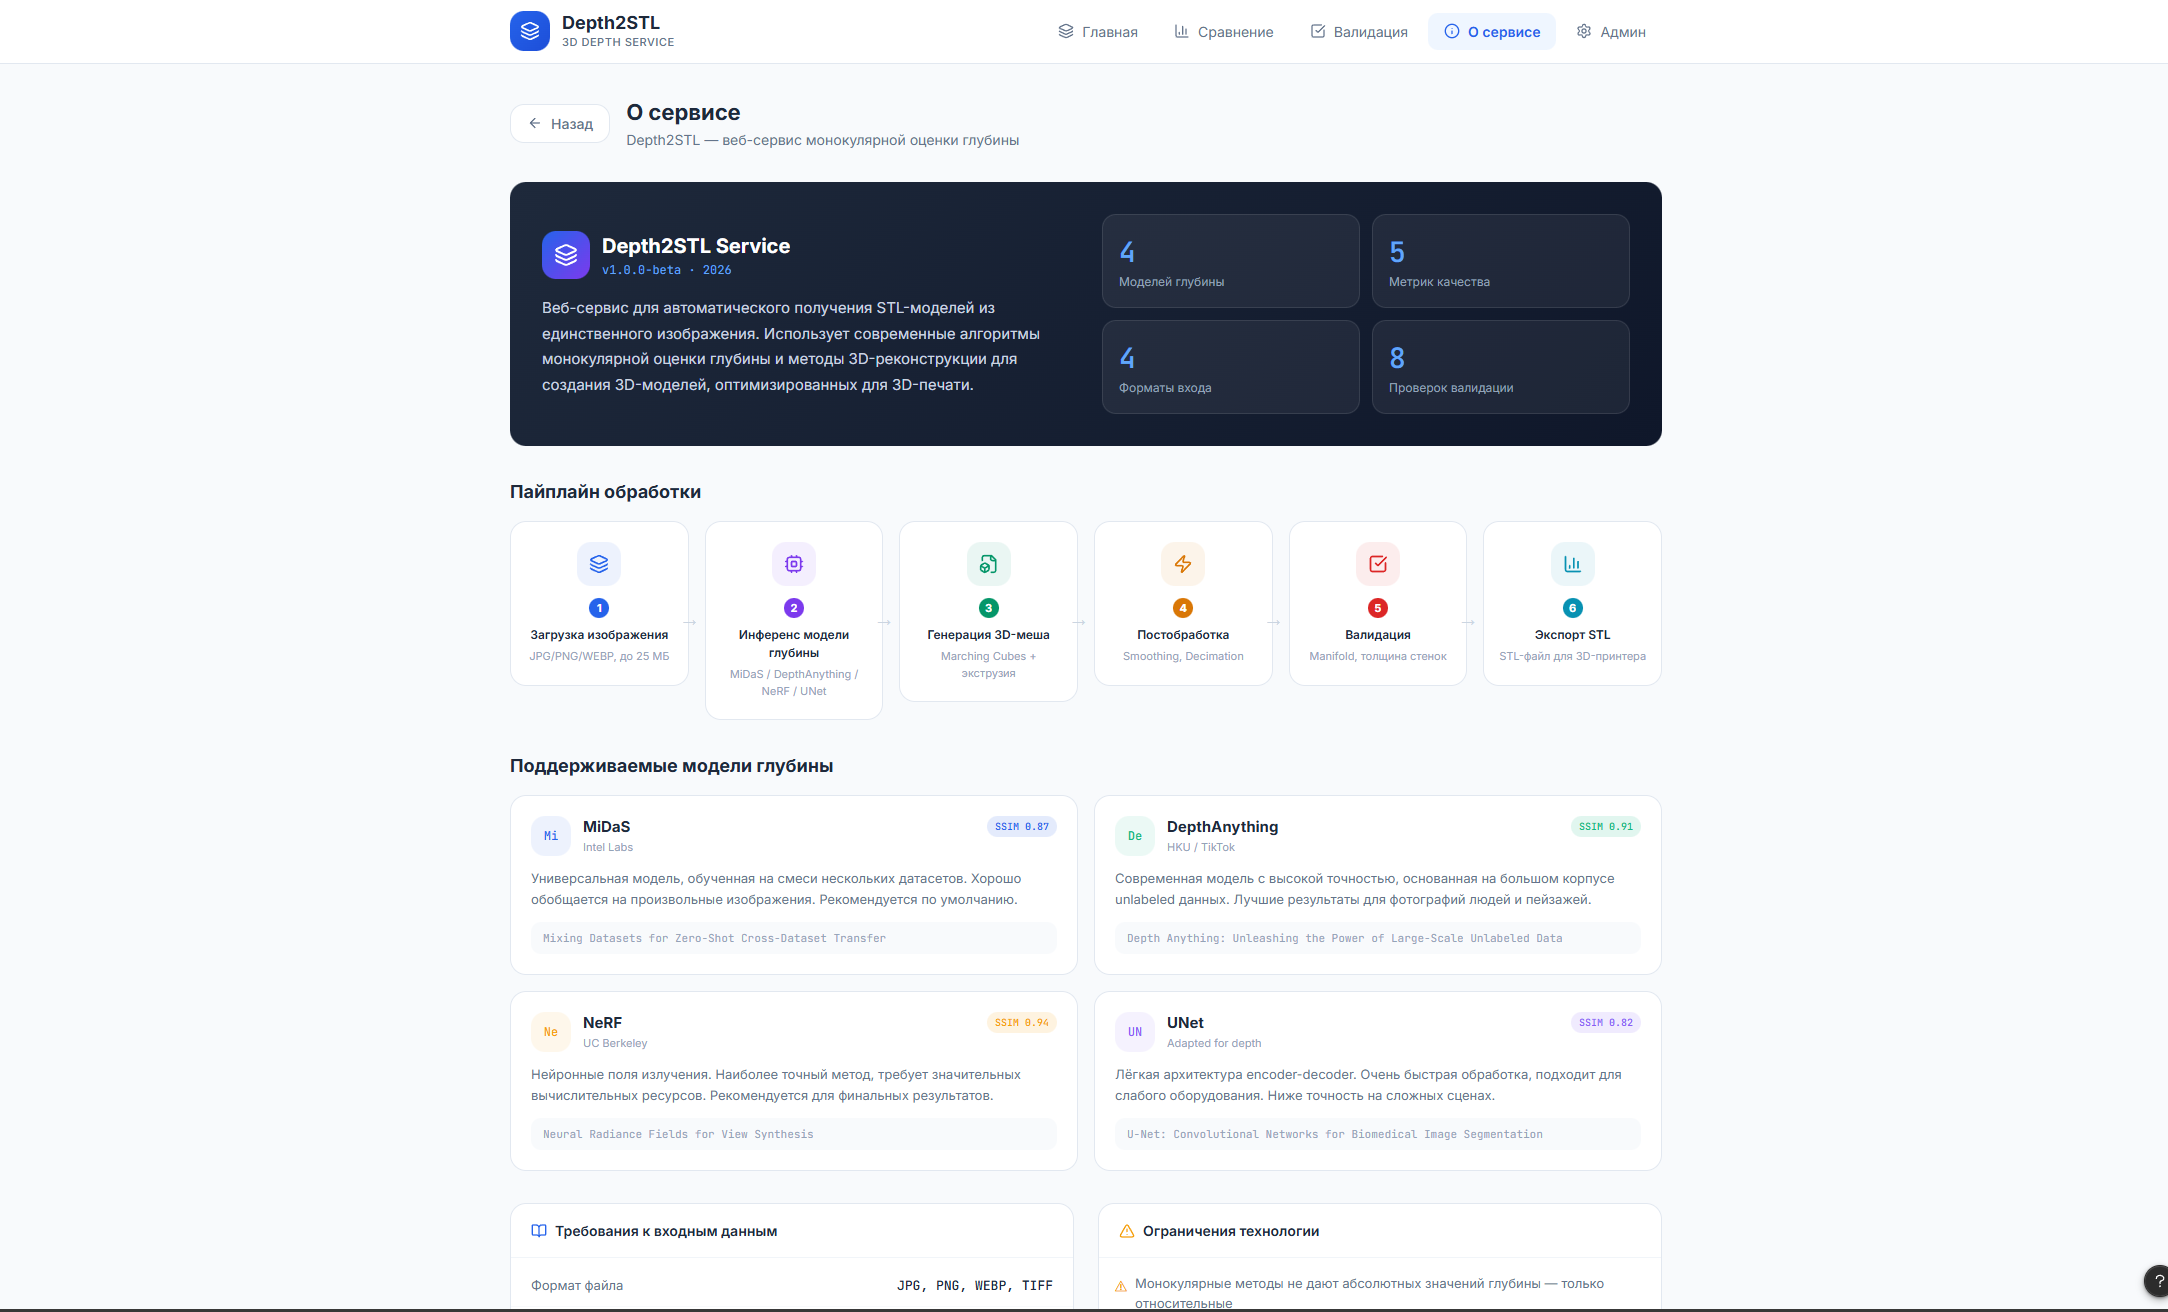

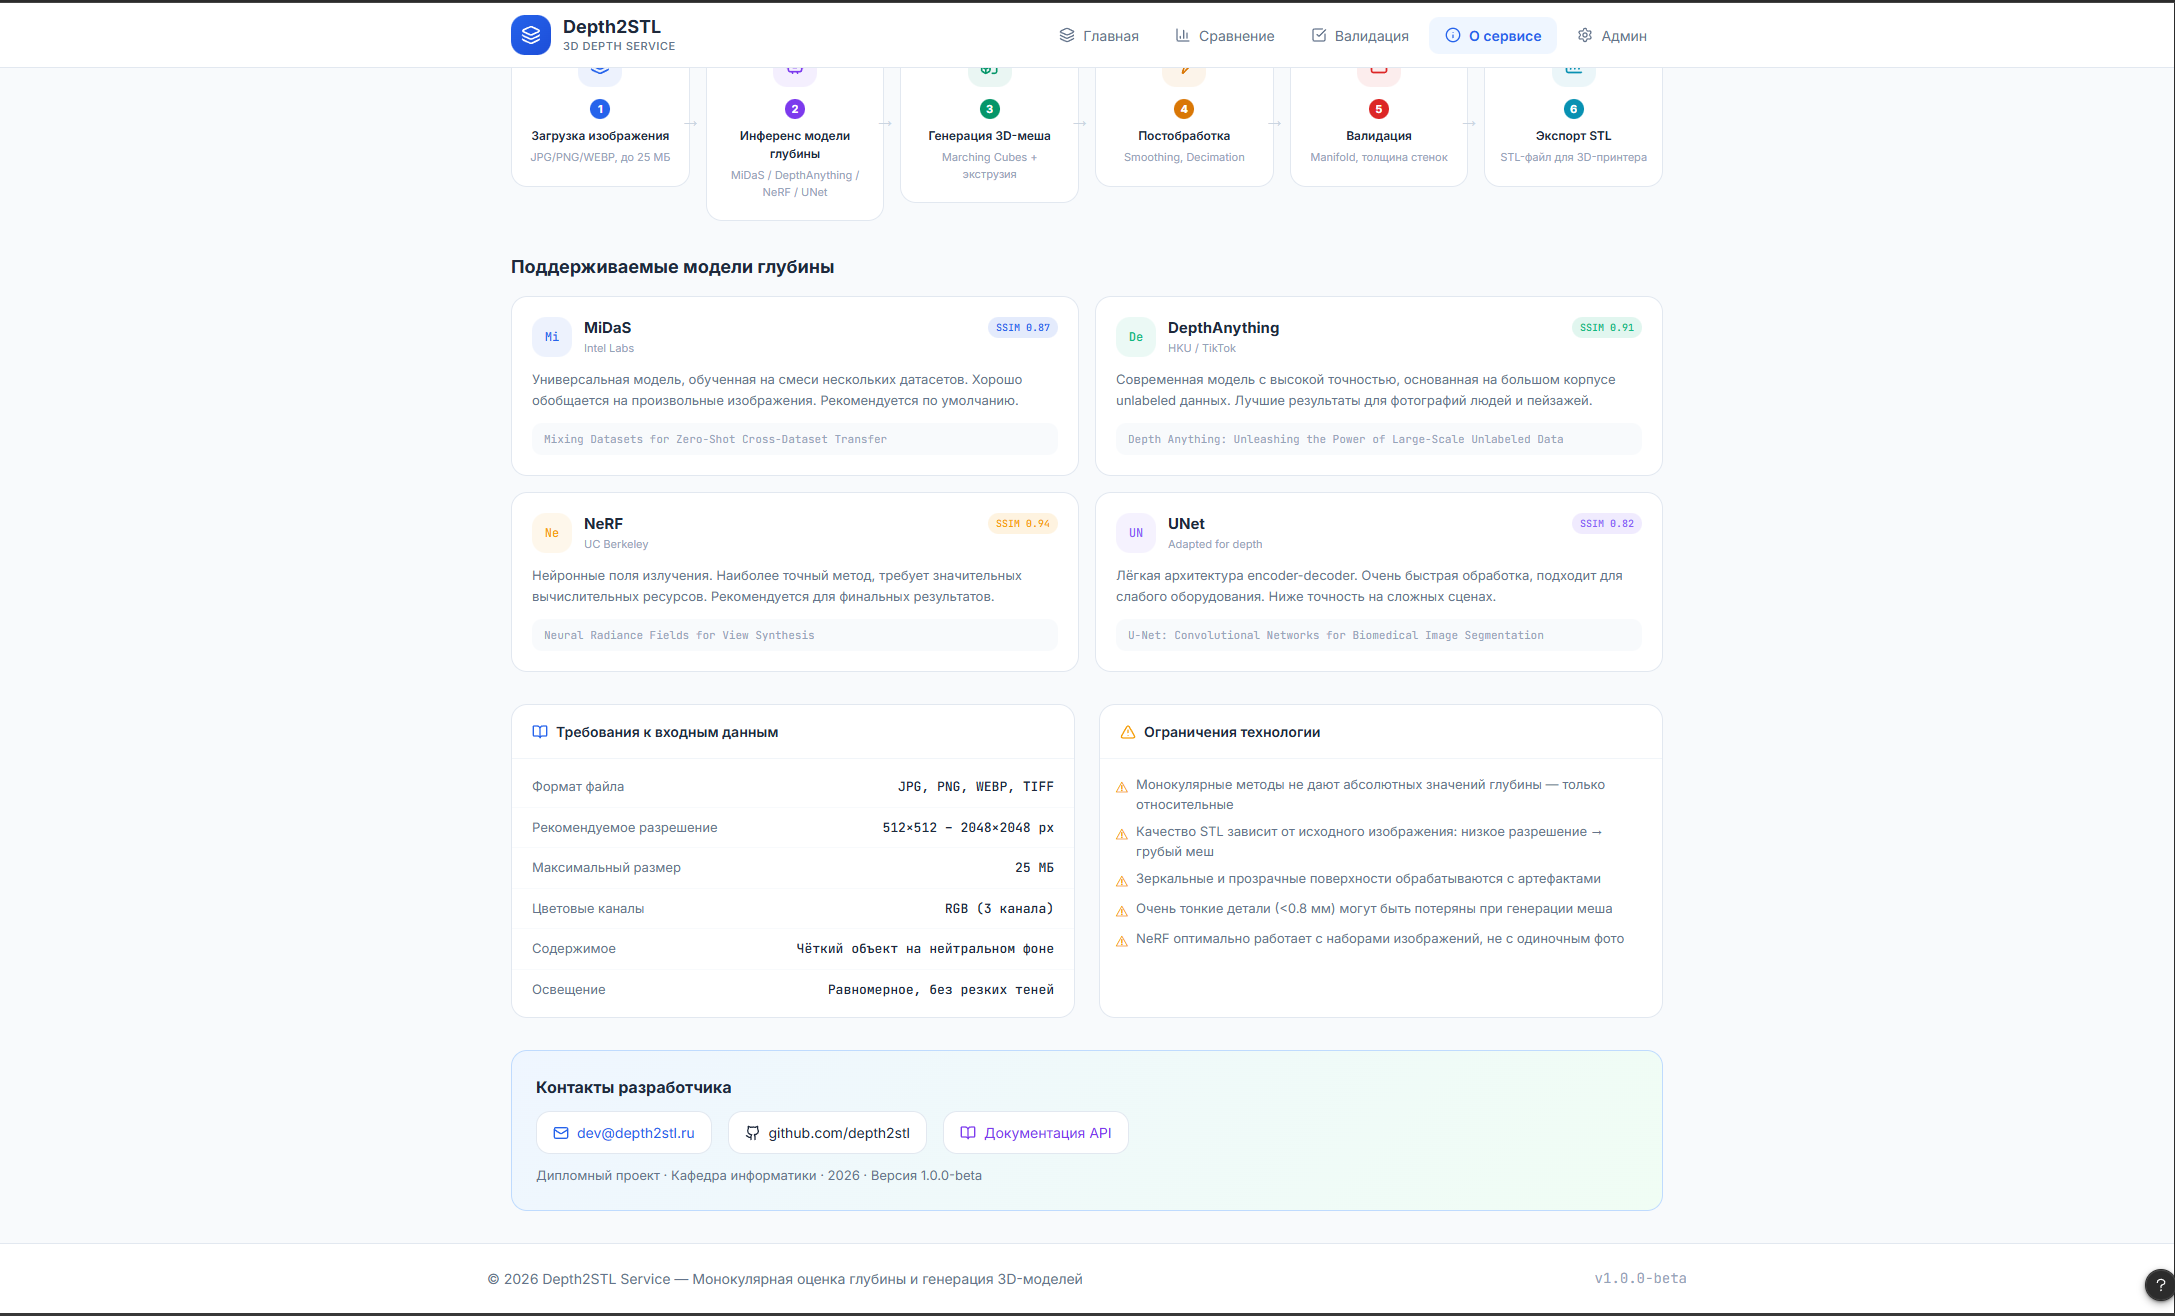

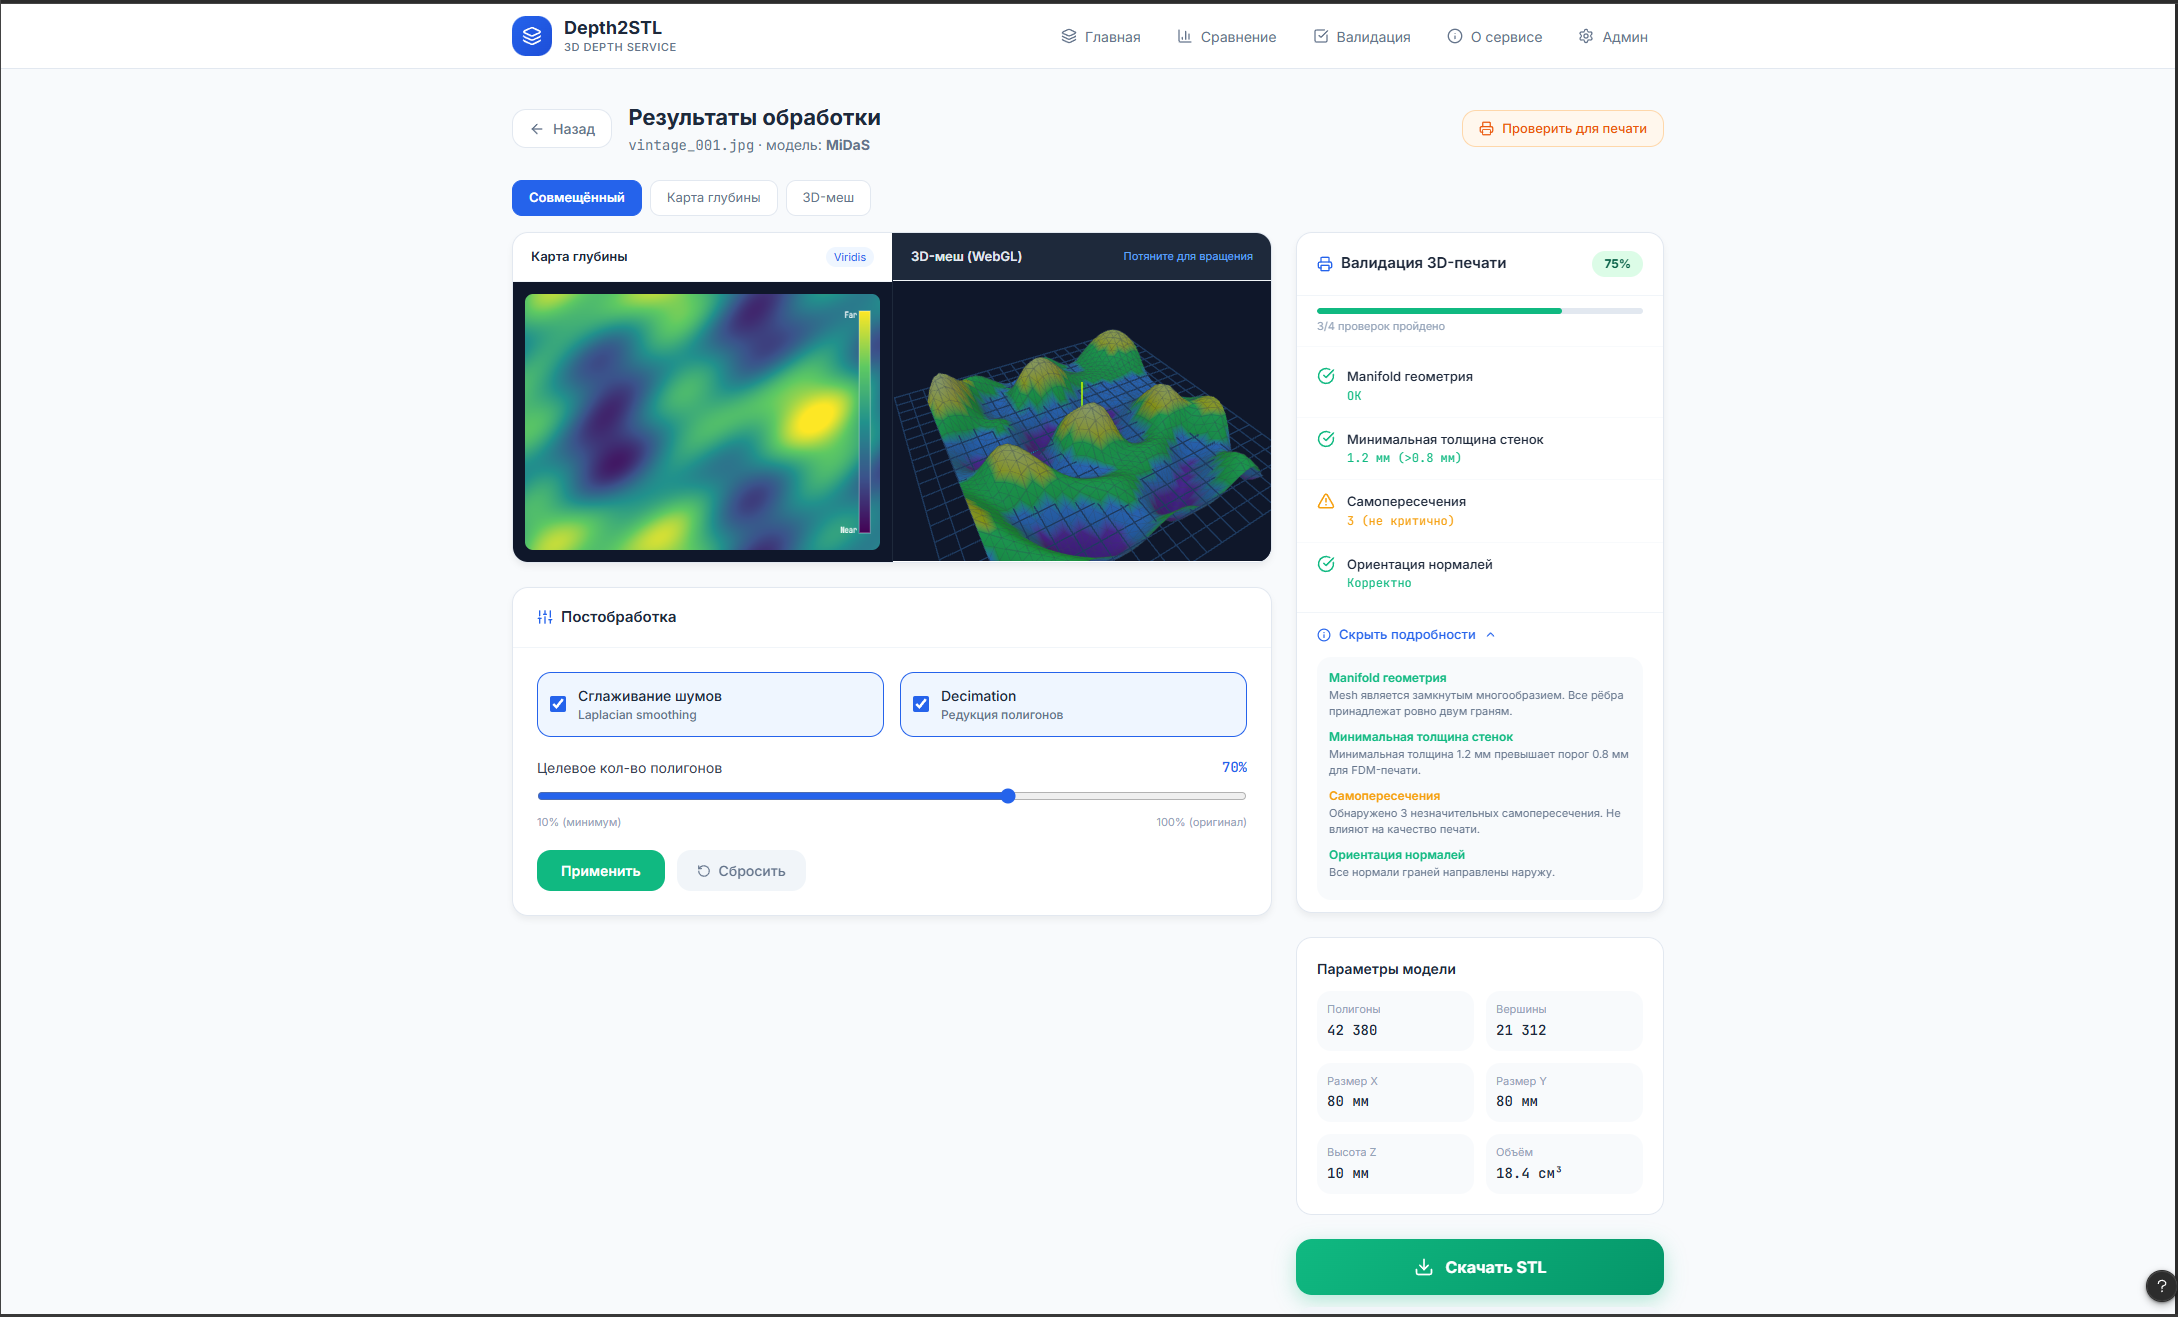

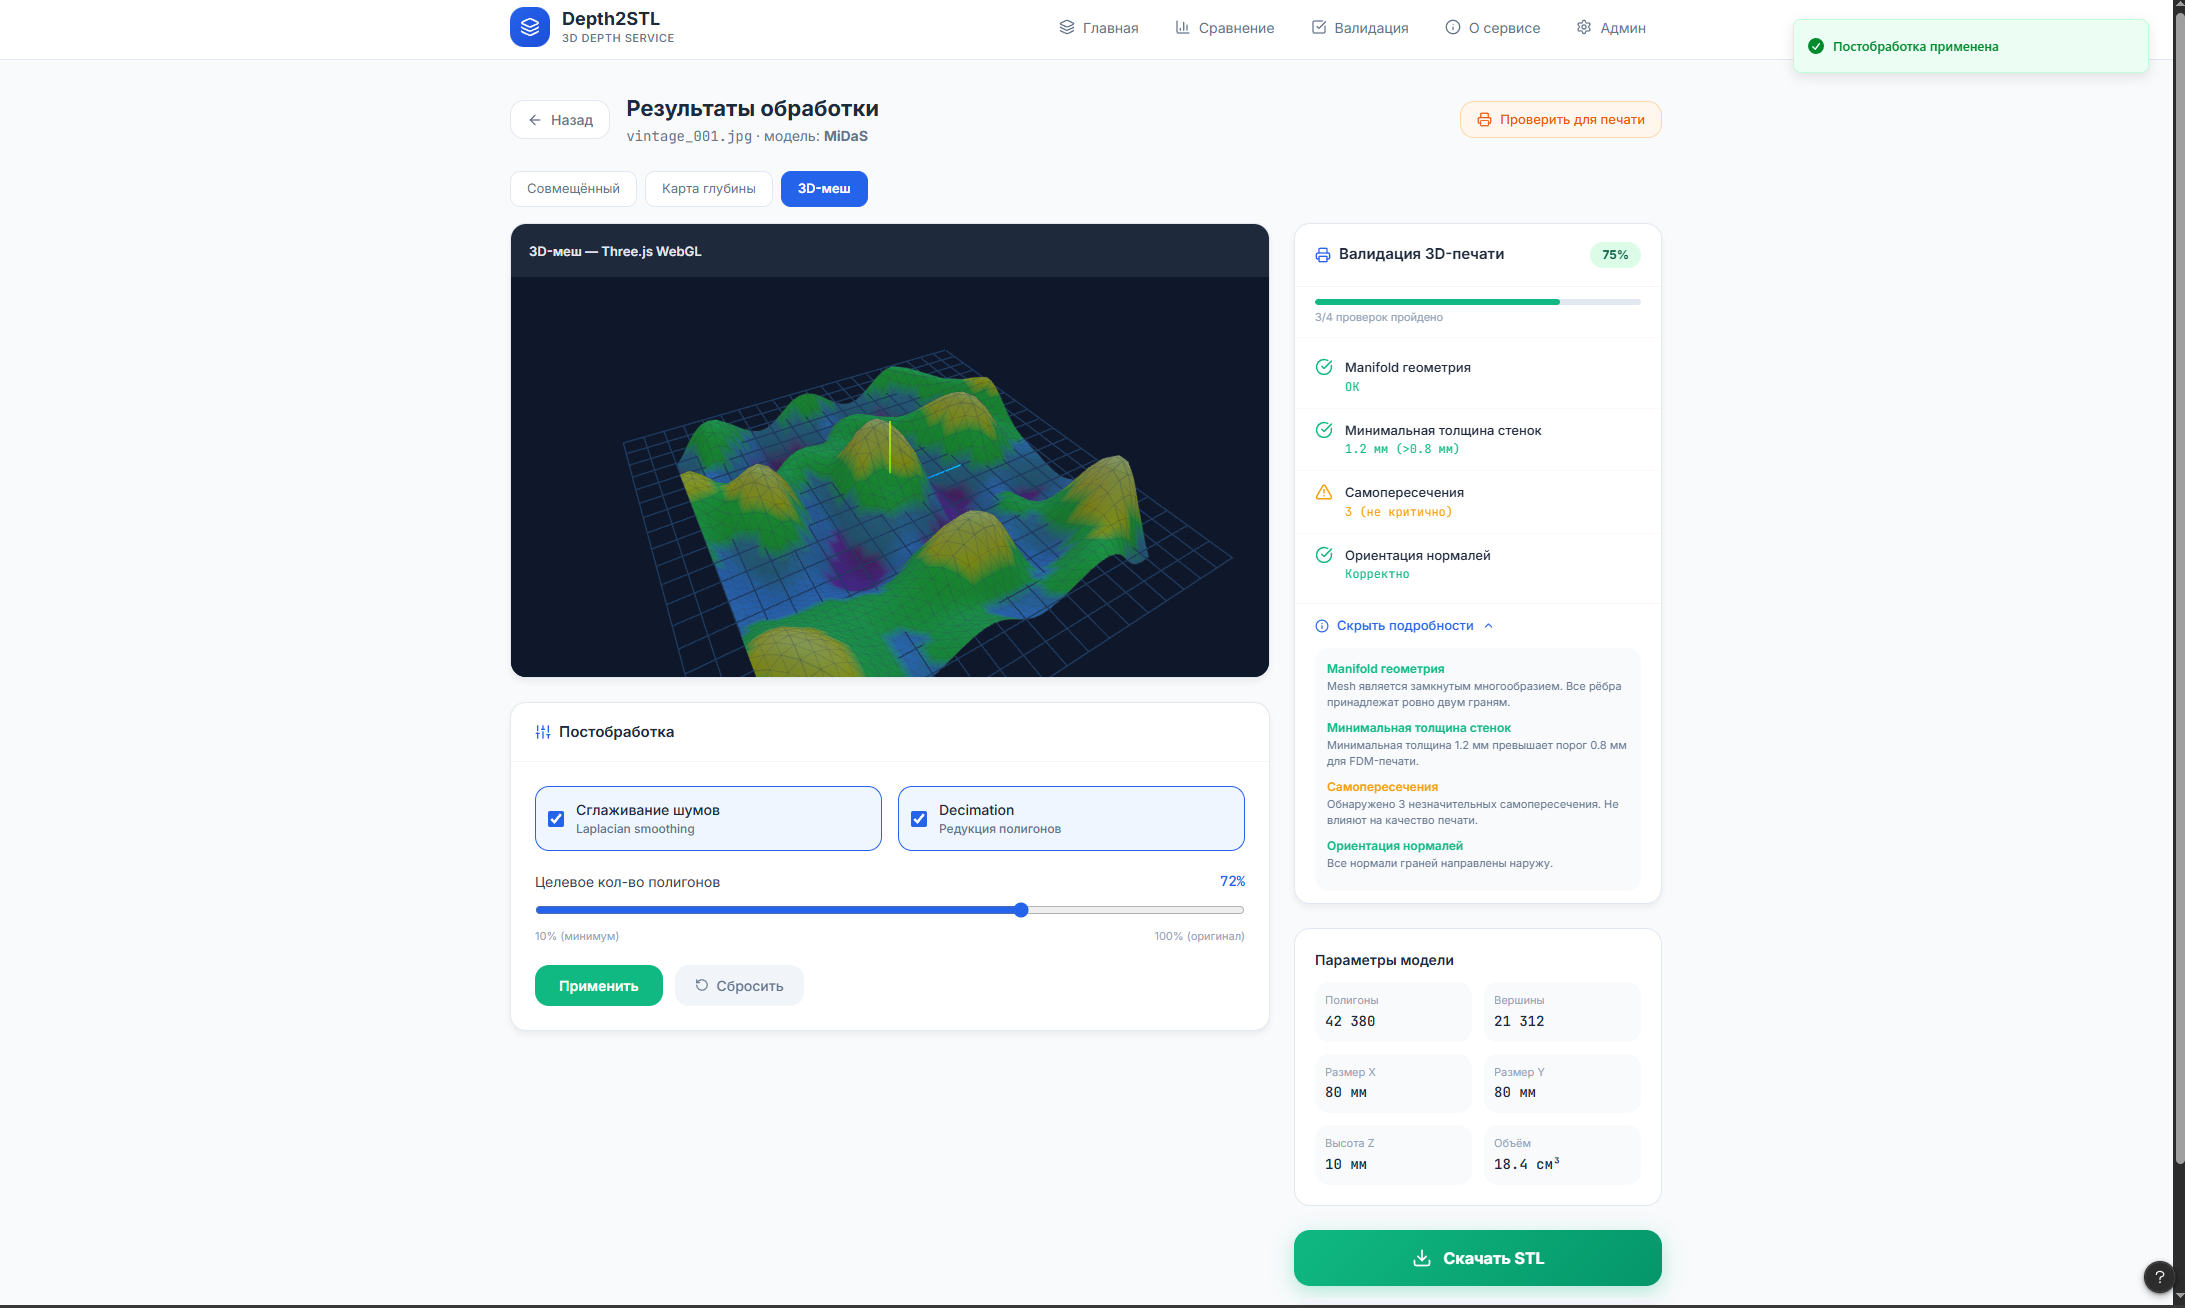